## Task 1

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import sys
import subprocess



## Task 2 Scrappping 

In [41]:
%%writefile book_spider.py
import scrapy

class BookSpider(scrapy.Spider):
    name = 'book_spider'
    start_urls = ['https://books.toscrape.com/catalogue/page-1.html']
    page_count = 1

    def parse(self, response):
        books = response.css('h3 a::attr(href)').getall()
        for book in books:
            yield response.follow(book, callback=self.parse_book)

        # Follow pagination up to at least 5 pages (to guarantee >100 books)
        next_page = response.css('li.next a::attr(href)').get()
        if next_page and self.page_count < 6:
            self.page_count += 1
            yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        yield {
            'title': response.css('div.product_main h1::text').get(),
            'category': response.xpath('//ul[@class="breadcrumb"]/li[3]/a/text()').get(),
            'price': response.css('p.price_color::text').get(),
            'rating': response.css('p.star-rating::attr(class)').get(),
            'availability': response.xpath('//th[text()="Availability"]/following-sibling::td/text()').get(),
            'description': response.xpath('//div[@id="product_description"]/following-sibling::p/text()').get(),
            'upc': response.xpath('//th[text()="UPC"]/following-sibling::td/text()').get(),
            'reviews': response.xpath('//th[text()="Number of reviews"]/following-sibling::td/text()').get(),
            'url': response.url
        }

Overwriting book_spider.py


## Task 3 Storing scrapped data

In [42]:
csv_file = "scraped_data.csv"

# Remove old file if you re-run this cell
if os.path.exists(csv_file):
    os.remove(csv_file)

print(f"Starting Scrapy using Python at: {sys.executable}")
print("Scraping in progress... Please wait about 15-30 seconds.")

# Run Scrapy command safely (UPDATED FOR SCRAPY 2.17.0)
command = f'"{sys.executable}" -m scrapy runspider book_spider.py -O {csv_file}'
result = subprocess.run(command, shell=True, capture_output=True, text=True)

if os.path.exists(csv_file):
    print(f"\nSUCCESS! '{csv_file}' has been created in:")
    print(os.path.abspath(csv_file))
else:
    print("\nERROR: Scrapy failed. Here is the log:")
    print(result.stderr)

Starting Scrapy using Python at: c:\Users\kau_shal\miniconda3\envs\ml\python.exe
Scraping in progress... Please wait about 15-30 seconds.

SUCCESS! 'scraped_data.csv' has been created in:
d:\ml assignments\202618001_kaushal_DS605\202618001_Lab_01\scraped_data.csv


## Task 4 Preprocessing 

In [43]:
# Load the successfully scraped data
raw_df = pd.read_csv('scraped_data.csv')

print("--- Task 1: Raw Data Report ---")
print(f"Total Scraped Records: {len(raw_df)}")
print(f"Total Missing Values:\n{raw_df.isnull().sum()}\n")
print(f"Duplicate UPC Values: {raw_df.duplicated(subset=['upc']).sum()}\n")

# Copy for cleaning
df = raw_df.copy()

# 1. Clean spaces and drop duplicate UPCs
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
df = df.drop_duplicates(subset=['upc'])

# 2. Handle missing descriptions
df['description'] = df['description'].fillna('No description available')

# 3. Format Price and Stock
df['price'] = df['price'].str.replace('£', '').astype(float)
df['stock_count'] = df['availability'].str.extract(r'(\d+)').astype(float)

# 4. Map Ratings
rating_map = {'star-rating One': 1, 'star-rating Two': 2, 'star-rating Three': 3, 
              'star-rating Four': 4, 'star-rating Five': 5}
df['rating'] = df['rating'].map(rating_map)

# 5. Create 3 Engineered Features
df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))
df['price_band'] = pd.cut(df['price'], bins=[0, 20, 40, 60, 100], labels=['Budget', 'Moderate', 'Expensive', 'Luxury'])
df['value_score'] = (df['rating'] / df['price']).round(3)

# Save cleaned dataset
df.to_csv('cleaned_data.csv', index=False)
print("--- Task 2: Preprocessing Complete ---")
print(f"Cleaned dataset saved as 'cleaned_data.csv' with {len(df)} records.")
df.head(3)

--- Task 1: Raw Data Report ---
Total Scraped Records: 120
Total Missing Values:
title           0
category        0
price           0
rating          0
availability    0
description     0
upc             0
reviews         0
url             0
dtype: int64

Duplicate UPC Values: 0

--- Task 2: Preprocessing Complete ---
Cleaned dataset saved as 'cleaned_data.csv' with 120 records.


,title,category,price,rating,availability,description,upc,reviews,url,stock_count,description_word_count,price_band,value_score
0,The Coming Woman: A Novel Based on the Life of...,Default,17.93,3,In stock (19 available),"""If you have a heart, if you have a soul, Kare...",e72a5dfc7e9267b2,0,https://books.toscrape.com/catalogue/the-comin...,19.0,568,Budget,0.167
1,Shakespeare's Sonnets,Poetry,20.66,4,In stock (19 available),This book is an important and complete collect...,30a7f60cd76ca58c,0,https://books.toscrape.com/catalogue/shakespea...,19.0,143,Moderate,0.194
2,The Dirty Little Secrets of Getting Your Dream...,Business,33.34,4,In stock (19 available),Drawing on his extensive experience evaluating...,2597b5a345f45e1b,0,https://books.toscrape.com/catalogue/the-dirty...,19.0,284,Moderate,0.120


## Task 4 Visualization 

C:\Users\kau_shal\AppData\Local\Temp\ipykernel_24480\1562695383.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, ax=axes[0, 1], palette='viridis')
C:\Users\kau_shal\AppData\Local\Temp\ipykernel_24480\1562695383.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['category'].isin(top_cats)], x='price', y='category', errorbar=None, ax=axes[1, 0], palette='magma')
C:\Users\kau_shal\AppData\Local\Temp\ipykernel_24480\1562695383.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='price', data

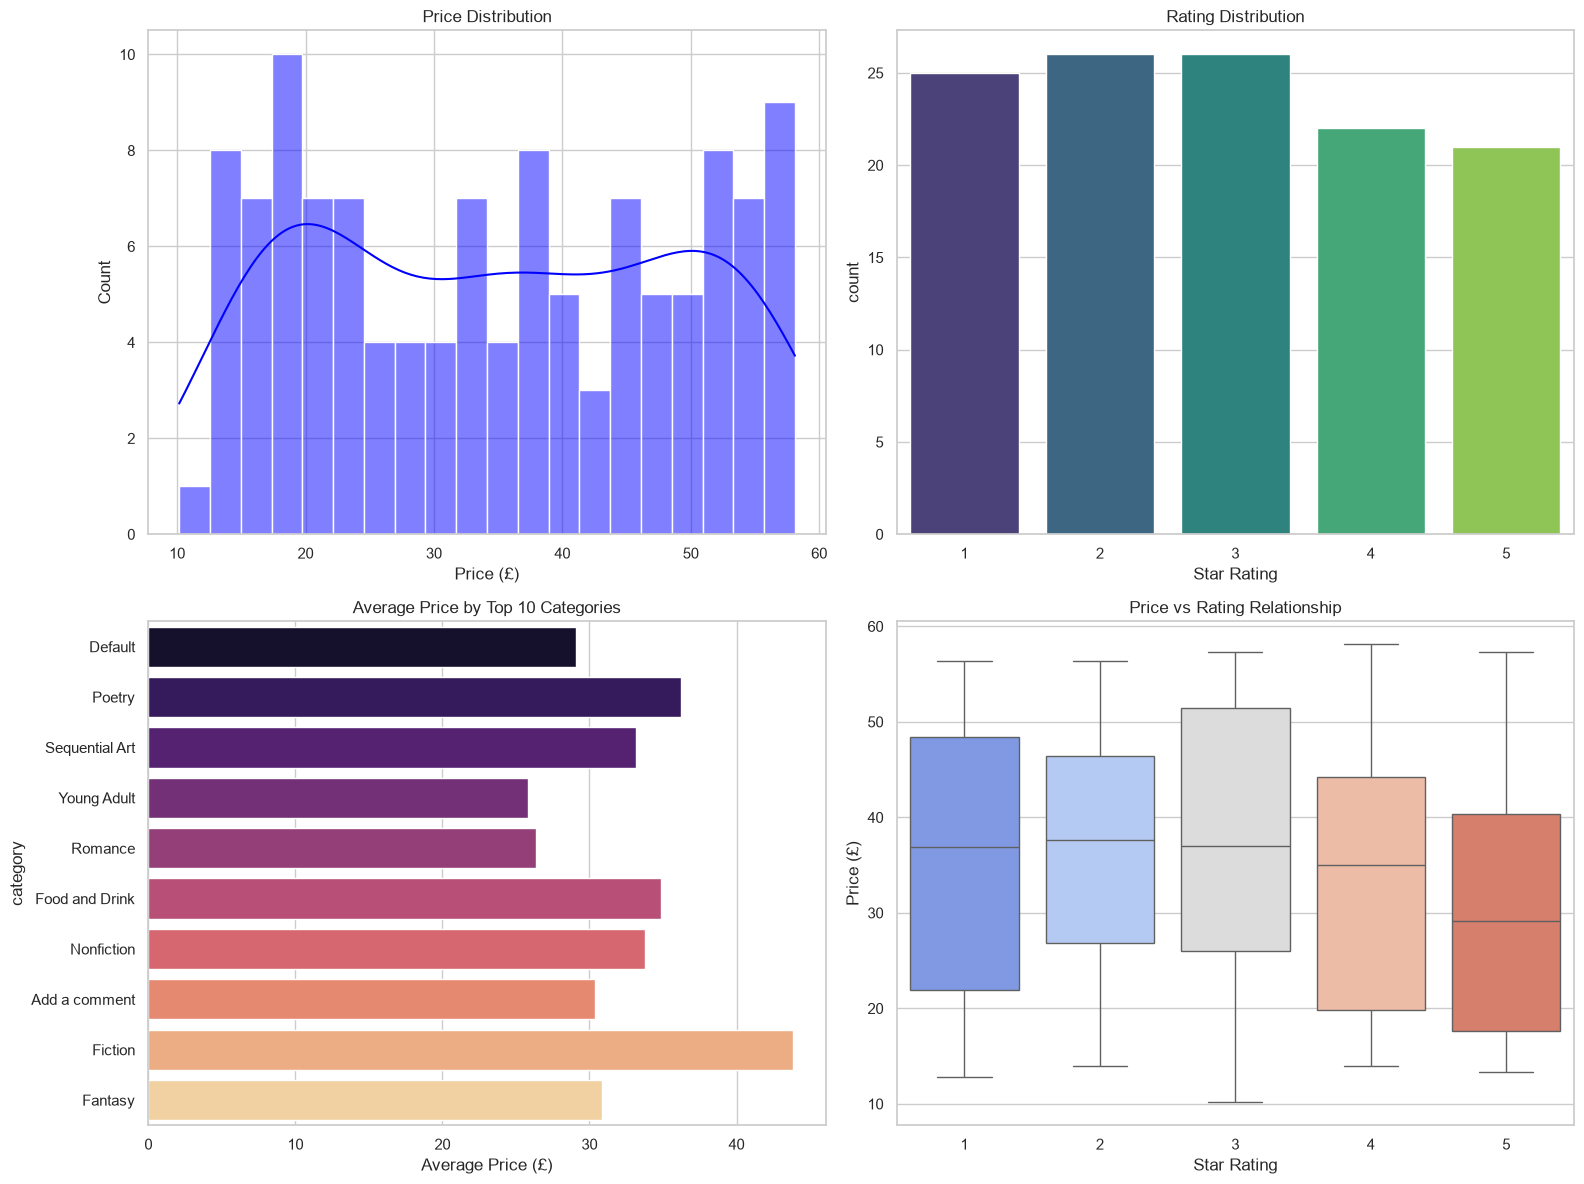

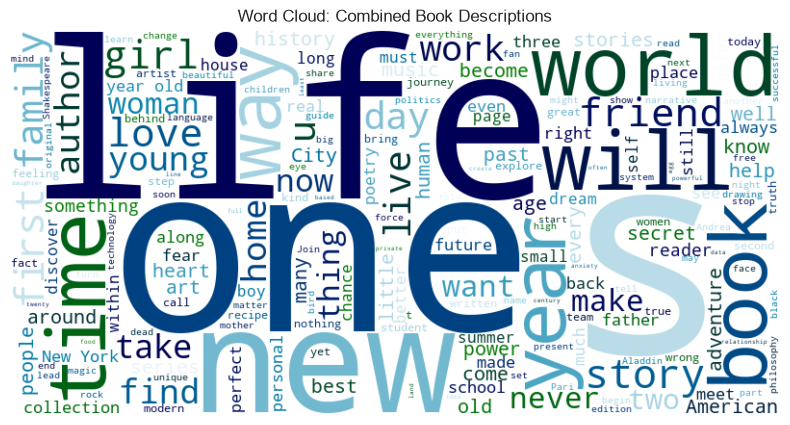

In [44]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Price Distribution
sns.histplot(df['price'], bins=20, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (£)')

# Plot 2: Rating Distribution
sns.countplot(x='rating', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Rating Distribution')
axes[0, 1].set_xlabel('Star Rating')

# Plot 3: Average Price by Top 10 Categories
top_cats = df['category'].value_counts().head(10).index
sns.barplot(data=df[df['category'].isin(top_cats)], x='price', y='category', errorbar=None, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Average Price by Top 10 Categories')
axes[1, 0].set_xlabel('Average Price (£)')

# Plot 4: Price vs Rating Relationship
sns.boxplot(x='rating', y='price', data=df, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Price vs Rating Relationship')
axes[1, 1].set_xlabel('Star Rating')
axes[1, 1].set_ylabel('Price (£)')

plt.tight_layout()
plt.show()

# Plot 5: Word Cloud
text = " ".join(desc for desc in df['description'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='ocean').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud: Combined Book Descriptions")
plt.show()


# Task 5 Summery 

## Price Distribution

### It shows how the prices of books are spread:Books are available in both low and high price ranges.
### Overall, the website offers books for different budgets, from cheaper to more expensive.

## Rating Distribution

### It shows how many books received each star rating.Books with 2-star and 3-star ratings are the most common.
### We conclude that the website has books with all types of ratings, from poor to excellent.

## Average Price by Top 10 Categories

### It compares the average price of books in different categories.
### Different book categories have different price ranges.
### This means the type of book can affect its average price.

## Price vs Rating Relationship

### Every star rating includes both cheap and expensive books. A higher rating does not always mean a higher price.
### there is no clear relationship between price and rating—book quality (rating) is not decided by price alone.

## Word Cloud

### The largest words (such as one, life, new, world, time, book, will) appear most often in the book descriptions, showing the most common themes and words used by authors.